In [2]:
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

with open('../data/SynReg/ap6-distributions.pkl', 'rb') as inp:
    data = pickle.load(inp)

In [2]:
distributions = data['distributions']
Y = data['Y']
APs = data['APs']
distributions

array([{'mean': 0.11505456638977896, 'y_std': 0.06090665392794814, 'w': array([[0.13339096, 0.24058962, 0.32713906, 0.85913749, 0.66609021]])},
       {'mean': 0.7721138207682436, 'y_std': 0.034207146150922255, 'w': array([[0.79888813, 0.67031877, 0.28711098, 0.4423637 , 0.36677431]])},
       {'mean': 0.8832540315244727, 'y_std': 0.01263794516923893, 'w': array([[0.91699637, 0.32203076, 0.37093787, 0.17346141, 0.52800653]])},
       {'mean': 0.036854583698208154, 'y_std': 0.032626510022246556, 'w': array([[0.17621354, 0.54623836, 0.33906042, 0.7576724 , 0.71470019]])},
       {'mean': 0.5908130063260473, 'y_std': 0.0996773764762588, 'w': array([[0.34958607, 0.1255835 , 0.35580942, 0.03667772, 0.68901665]])}],
      dtype=object)

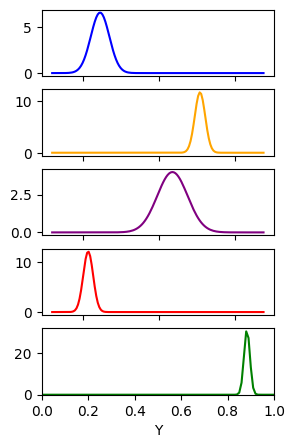

In [109]:
fig, axs = plt.subplots(5, figsize=(3, 5))
x_axis = np.arange(-0.2, 1.2, 0.01) 
axs[0].plot(x_axis, norm.pdf(x_axis, distributions[0]['mean'], distributions[0]['y_std']), 'blue', label='Deployment 1') 
axs[1].plot(x_axis, norm.pdf(x_axis, distributions[1]['mean'], distributions[1]['y_std']), 'orange', label='Deployment 2') 
axs[2].plot(x_axis, norm.pdf(x_axis, distributions[4]['mean'], distributions[4]['y_std']), 'purple', label='Deployment 5') 
axs[3].plot(x_axis, norm.pdf(x_axis, distributions[3]['mean'], distributions[3]['y_std']), 'red', label='Deployment 4') 
axs[4].plot(x_axis, norm.pdf(x_axis, distributions[2]['mean'], distributions[2]['y_std']), 'green', label='Deployment 3') 
plt.xlabel('Y')
for ax in fig.get_axes():
    ax.label_outer()
#plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 32)
plt.savefig('stacked_deployment_distributions.png')
plt.show()

In [4]:
with open('../statistics/gmm_of_users.pkl', 'rb') as inp:
    gmm_of_users = pickle.load(inp)

In [5]:
gmm_of_users

{0: GaussianMixture(n_components=5, random_state=0),
 1: GaussianMixture(n_components=5, random_state=0),
 2: GaussianMixture(n_components=5, random_state=0),
 3: GaussianMixture(n_components=5, random_state=0),
 4: GaussianMixture(n_components=5, random_state=0),
 5: GaussianMixture(n_components=5, random_state=0),
 6: GaussianMixture(n_components=5, random_state=0),
 7: GaussianMixture(n_components=5, random_state=0),
 8: GaussianMixture(n_components=5, random_state=0),
 9: GaussianMixture(n_components=5, random_state=0),
 10: GaussianMixture(n_components=5, random_state=0),
 11: GaussianMixture(n_components=5, random_state=0),
 12: GaussianMixture(n_components=5, random_state=0),
 13: GaussianMixture(n_components=5, random_state=0),
 14: GaussianMixture(n_components=5, random_state=0),
 15: GaussianMixture(n_components=5, random_state=0),
 16: GaussianMixture(n_components=5, random_state=0),
 17: GaussianMixture(n_components=5, random_state=0),
 18: GaussianMixture(n_components=5, r

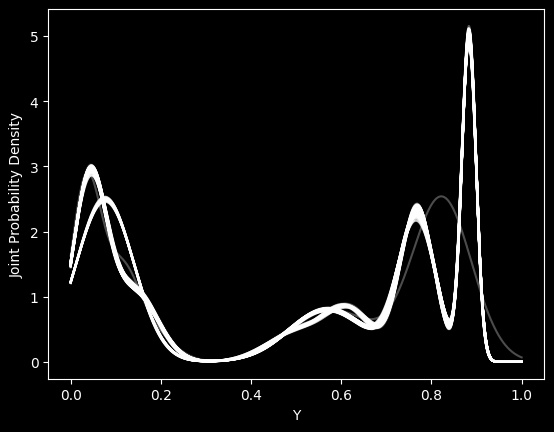

In [23]:
fig = plt.figure()
plt.style.use("dark_background")
ax = fig.add_subplot(111)
x = np.linspace(0, 1, 1000).reshape(1000,1)

alpha = 0.0
epochs = len(gmm_of_users.keys())
for i in gmm_of_users.keys():
    logprob = gmm_of_users[i].score_samples(x)
    pdf = np.exp(logprob)
    #print np.max(pdf) -> 19.8409464401 !?
    ax.plot(x, pdf, 'white', alpha=alpha)
    alpha += 1/epochs
plt.xlabel('Y')
plt.ylabel('Joint Probability Density')
plt.savefig('gmm.png', transparent=True)
plt.show()

## Fit a simple model on the synthetic dataset

In [1]:
from data.SynReg.dataset import DatasetGenerator
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

dataset_generator = DatasetGenerator(10000, 2, 5, train_ratio=0.7, lookback=1,
                                         steps=1, random_seed=13132112, save_distributions='./distributions.pkl',
                                     population_dependent=False)

      - APs for training/validation: [0, 1]
      - APs for test: [0, 1]
      - Training samples: 11198
      - Validation samples: 2800
      - Test samples: 5998


In [3]:
train_data, train_target, train_ap = dataset_generator.getSplit('train')
validation_data, validation_target, validation_ap = dataset_generator.getSplit('validation')
train_data = train_data[:, None, :, :]
validation_data = validation_data[:, None, :, :]
print(validation_data.shape)

(2800, 1, 1, 6)


In [4]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, stride=2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(6, 16,stride=2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32, 32)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(-1, 32)
        x = self.fc1(x)
        x = self.fc2(x)
        return x
loss_fn = torch.nn.L1Loss()
model = Model()
optimizer =  torch.optim.Adam(params=model.parameters(), lr=1e-4)

In [5]:
X_train_tensor = torch.from_numpy(train_data).float()
Y_train_tensor = torch.from_numpy(train_target).float()
train_dataset = TensorDataset(X_train_tensor,Y_train_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=32) # create your dataloader
max_epochs = 100

model.train()
for i in range(max_epochs):
    for inputs, outputs in train_dataloader:
        prediction = model(inputs)
        loss = loss_fn(prediction, outputs) 
        optimizer.zero_grad()
        loss.backward()        
        optimizer.step()
    if i % 10 == 0:
        print('{}: {}'.format(i, loss.item()))



0: 0.16507811844348907
10: 0.018193166702985764
20: 0.014093213714659214
30: 0.011270837858319283
40: 0.009148434735834599
50: 0.007896849885582924
60: 0.007393719162791967
70: 0.007283744867891073
80: 0.007340257056057453
90: 0.007422178518027067


In [6]:
X_validation_tensor = torch.from_numpy(validation_data).float()
Y_validation_tensor = torch.from_numpy(validation_target).float()
validation_dataset = TensorDataset(X_validation_tensor,Y_validation_tensor)
validation_dataloader = DataLoader(validation_dataset, batch_size=32) # create your dataloader

model.eval()
ground_truth = []
predictions = []
for inputs, outputs in validation_dataloader:
        prediction = model(inputs)
        predictions.extend(prediction.data.numpy().squeeze())
        ground_truth.extend(outputs.data.numpy().squeeze())

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

print('MAE: {}'.format(mean_absolute_error(ground_truth, predictions)))
print('MSE: {}'.format(mean_squared_error(ground_truth, predictions)))
print('MAPE: {}'.format(mean_absolute_percentage_error(ground_truth, predictions)))

MAE: 0.008259267546236515
MSE: 0.00010855089203687385
MAPE: 0.26558929681777954


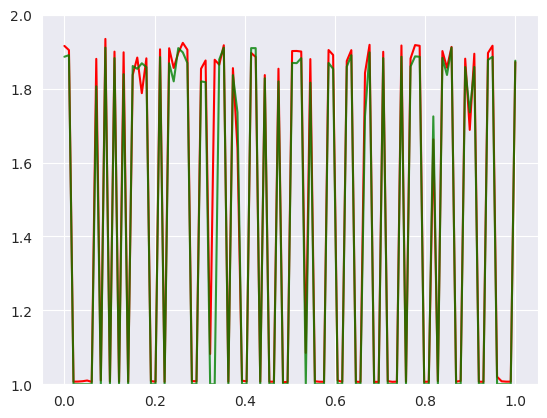

In [12]:
with open('../centralized_predictions.pkl', 'rb') as inp:
    centralized_info = pickle.load(inp)

fig = plt.figure()
ax = fig.add_subplot(111)
x = np.linspace(0, 1, len(centralized_info['y_pred'][:100])).reshape(-1, 1)

ax.plot(x, centralized_info['y_pred'][:100], 'red')
ax.plot(x, centralized_info['y_true'][:100], 'green', alpha=0.8)
ax.set_ylim(1, 2)
plt.show()

In [12]:
for i in range(len(predictions)):
    print('{}:{}'.format(predictions[i], ground_truth[i]))

0.013553887605667114:0.010968017391860485
0.07680317759513855:0.08011232316493988
0.05222387611865997:0.04783393442630768
0.09529218077659607:0.09908458590507507
0.13179302215576172:0.13411448895931244
0.306692510843277:0.29441189765930176
0.36966025829315186:0.3736056983470917
0.08349627256393433:0.08104856312274933
0.4135235846042633:0.4035651683807373
-0.011163972318172455:-0.009269236586987972
0.10536220669746399:0.10042216628789902
0.41302070021629333:0.399869441986084
0.16033399105072021:0.15010806918144226
0.37017568945884705:0.3684152662754059
0.10845218598842621:0.1121760904788971
0.42968007922172546:0.43500378727912903
0.051832303404808044:0.025674713775515556
-0.007657885551452637:-0.008573068305850029
0.10127365589141846:0.08811698853969574
-0.027198605239391327:-0.05342898517847061
0.05792911350727081:0.05097405984997749
0.030810490250587463:0.01738440804183483
0.4559811055660248:0.4443705081939697
0.4724738299846649:0.4622165262699127
0.05942028760910034:0.055281855165958

In [63]:
with open('../results/SynReg-user5-alpha0-ratio0.7_Centralized_0.01_5u_32b_200_0.pkl', 'rb') as inp:
    centralized_info = pickle.load(inp)
    
with open('../results/SynReg-user5-alpha0-ratio0.7_FedGen_0.01_5u_32b_200_0_embed1.pkl', 'rb') as inp:
    collaborative_info = pickle.load(inp)

isolated_info = []
with open('../results/SynReg-user5-alpha0-ratio0.7_Isolated_0.01_5u_32b_200_0_t0.pkl', 'rb') as inp:
    isolated_info.append(pickle.load(inp))
with open('../results/SynReg-user5-alpha0-ratio0.7_Isolated_0.01_5u_32b_200_0_t1.pkl', 'rb') as inp:
    isolated_info.append(pickle.load(inp))
with open('../results/SynReg-user5-alpha0-ratio0.7_Isolated_0.01_5u_32b_200_0_t2.pkl', 'rb') as inp:
    isolated_info.append(pickle.load(inp))
with open('../results/SynReg-user5-alpha0-ratio0.7_Isolated_0.01_5u_32b_200_0_t3.pkl', 'rb') as inp:
    isolated_info.append(pickle.load(inp))
with open('../results/SynReg-user5-alpha0-ratio0.7_Isolated_0.01_5u_32b_200_0_t4.pkl', 'rb') as inp:
    isolated_info.append(pickle.load(inp))

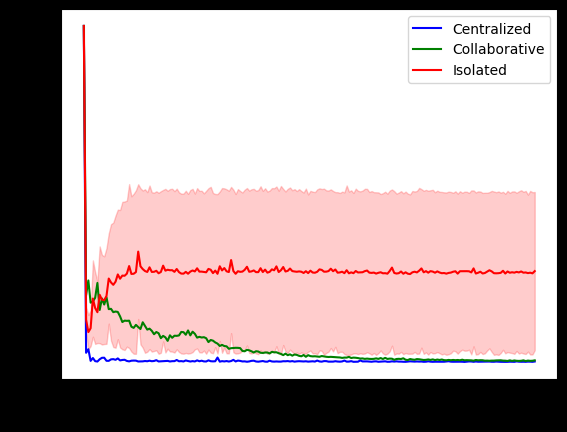

In [69]:
fig = plt.figure()
plt.style.use("default")
ax = fig.add_subplot(111)

centralized_mse = [epoch_info['mse'] for epoch_info in centralized_info['glob_test_metric']]
collaborative_mse = [epoch_info['mse'] for epoch_info in collaborative_info['glob_test_metric']]
isolated_mse = np.array([[epoch_info['mse'] for epoch_info in trial['glob_test_metric'] ] for trial in isolated_info])
isolated_mse_error = np.std(isolated_mse, axis=0)
isolated_mse_average = np.mean(isolated_mse, axis=0)
epochs = len(gmm_of_users.keys())
#print np.max(pdf) -> 19.8409464401 !?
ax.plot(range(len(centralized_info['glob_test_metric'])), centralized_mse, 'blue', label='Centralized')
ax.plot(range(len(centralized_info['glob_test_metric'])), collaborative_mse, 'green', label='Collaborative')
plt.plot(range(len(isolated_mse_average)), isolated_mse_average, 'red', label='Isolated')
plt.fill_between(range(len(isolated_mse_average)), isolated_mse_average-isolated_mse_error, isolated_mse_average+isolated_mse_error, alpha=0.2, color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig('MSE.png', transparent=True)
plt.show()

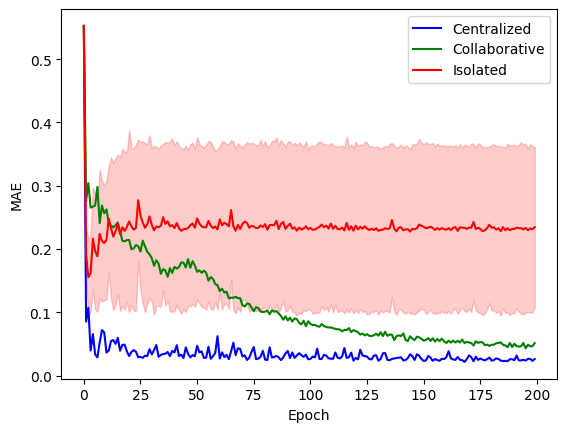

In [70]:
fig = plt.figure()
plt.style.use("default")
ax = fig.add_subplot(111)

centralized_mae = [epoch_info['mae'] for epoch_info in centralized_info['glob_test_metric']]
collaborative_mae = [epoch_info['mae'] for epoch_info in collaborative_info['glob_test_metric']]
isolated_mae = np.array([[epoch_info['mae'] for epoch_info in trial['glob_test_metric'] ] for trial in isolated_info])
isolated_mae_error = np.std(isolated_mae, axis=0)
isolated_mae_average = np.mean(isolated_mae, axis=0)
epochs = len(gmm_of_users.keys())
#print np.max(pdf) -> 19.8409464401 !?
ax.plot(range(len(centralized_info['glob_test_metric'])), centralized_mae, 'blue', label='Centralized')
ax.plot(range(len(centralized_info['glob_test_metric'])), collaborative_mae, 'green', label='Collaborative')
plt.plot(range(len(isolated_mae_average)), isolated_mae_average, 'red', label='Isolated')
plt.fill_between(range(len(isolated_mae_average)), isolated_mae_average-isolated_mae_error, isolated_mae_average+isolated_mae_error, alpha=0.2, color='red')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.savefig('MAE.png', transparent=True)
plt.show()

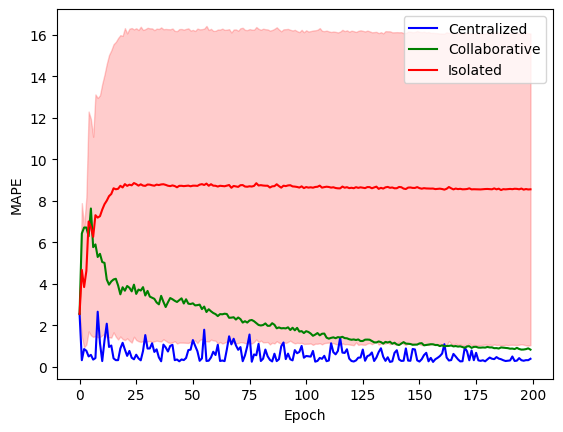

In [71]:
fig = plt.figure()
plt.style.use("default")
ax = fig.add_subplot(111)

centralized_mape = [epoch_info['mape'] for epoch_info in centralized_info['glob_test_metric']]
collaborative_mape = [epoch_info['mape'] for epoch_info in collaborative_info['glob_test_metric']]
isolated_mape = np.array([[epoch_info['mape'] for epoch_info in trial['glob_test_metric'] ] for trial in isolated_info])
isolated_mape_error = np.std(isolated_mape, axis=0)
isolated_mape_average = np.mean(isolated_mape, axis=0)
epochs = len(gmm_of_users.keys())
#print np.max(pdf) -> 19.8409464401 !?
ax.plot(range(len(centralized_info['glob_test_metric'])), centralized_mape, 'blue', label='Centralized')
ax.plot(range(len(centralized_info['glob_test_metric'])), collaborative_mape, 'green', label='Collaborative')
plt.plot(range(len(isolated_mape_average)), isolated_mape_average, 'red', label='Isolated')
plt.fill_between(range(len(isolated_mape_average)), isolated_mape_average-isolated_mape_error, isolated_mape_average+isolated_mape_error, alpha=0.2, color='red')
plt.xlabel('Epoch')
plt.ylabel('MAPE')
plt.legend()
plt.savefig('MAPE.png', transparent=True)
plt.show()

In [117]:
(np.array(centralized_mape) - np.array(collaborative_mape))[-5:]

array([-0.51073601, -0.54180522, -0.53127144, -0.57153132, -0.44082206])

## Dealing with the imbalanced data

In [1]:
from sklearn import preprocessing
from data.FlagsRegression.dataset import load_dataset
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import fclusterdata
import pickle
import matplotlib
from sklearn.metrics.pairwise import pairwise_distances
import time

In [2]:
raw_data = load_dataset(path='/home/dsalami/dataset/aggregated/pickle_2019-05-13-on7_2min.pkl', normalize=True)

In [54]:
ground_truth_kb = raw_data['Bytes'][raw_data['AP ID'] == raw_data['AP ID'].iloc[0]]
print(raw_data.keys())

Index(['datetime', 'Index', 'Bytes', 'Active Connections', 'Active Users',
       'AP ID', 'day_of_week', 'day_of_week_sin', 'day_of_week_cos',
       'hour_of_day', 'hour_of_day_sin', 'hour_of_day_cos'],
      dtype='object')


In [3]:
aps = np.unique(raw_data['AP ID'])
np.random.shuffle(aps)

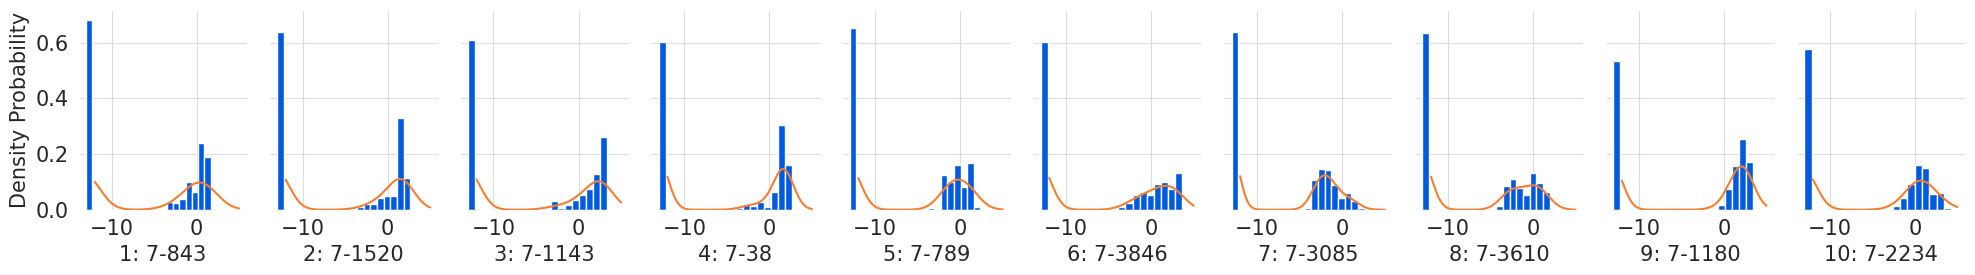

In [4]:
font = {'size'   : 15}
matplotlib.rc('font', **font)
matplotlib.rcParams['grid.color'] = '#dcddde'

number_of_aps = 10
fig, axs = plt.subplots(1, number_of_aps, sharey=True, tight_layout=True, figsize=(20, 3))
n_bins = 20
xx = np.linspace(-12, 5, 1000)
for i in range(number_of_aps):
    axs[i].hist(raw_data['Bytes'][raw_data['AP ID'] == aps[i]], bins=n_bins, density=True, color='#005ae1')
    kde0 = stats.gaussian_kde(raw_data['Bytes'][raw_data['AP ID'] == aps[i]])
    axs[i].plot(xx, kde0(xx), color='#f47f31')
    if i == 0:
        axs[i].set_ylabel('Density Probability')
    axs[i].set_xlabel(f'{i+1}: {aps[i]}')
    axs[i].set_facecolor((1, 1, 1))

plt.savefig('five_histograms.png')

In [5]:
# Calculates kl divergence of two gmms
def gmm_kl(gmm_p, gmm_q, n_samples=10**5):
    X, _ = gmm_p.sample(n_samples)
    log_p_X = gmm_p.score_samples(X)
    log_q_X = gmm_q.score_samples(X)
    return log_p_X.mean() - log_q_X.mean()

def gmm_js(gmm_p, gmm_q, n_samples=10**5):
    X, _ = gmm_p.sample(n_samples)
    log_p_X = gmm_p.score_samples(X)
    log_q_X = gmm_q.score_samples(X)
    log_mix_X = np.logaddexp(log_p_X, log_q_X)

    Y, _ = gmm_q.sample(n_samples)
    log_p_Y = gmm_p.score_samples(Y)
    log_q_Y = gmm_q.score_samples(Y)
    log_mix_Y = np.logaddexp(log_p_Y, log_q_Y)

    return (log_p_X.mean() - (log_mix_X.mean() - np.log(2))
            + log_q_Y.mean() - (log_mix_Y.mean() - np.log(2))) / 2


In [6]:
gmms = {}
gmm_parameters = []
for i in list(range(len(aps[:100]))):
    original_data = raw_data['Bytes'][raw_data['AP ID'] == aps[i]].to_numpy()
    gmms[aps[i]] = GaussianMixture(n_components=10, random_state=0).fit(original_data.reshape(-1, 1))
    gmm_parameters.append([np.array(gmms[aps[i]].means_).squeeze(), np.array(gmms[aps[i]].covariances_).squeeze()])
gmm_parameters = np.array(gmm_parameters)

In [8]:
with open('../distances.pkl', "rb") as f:
    distances = pickle.load(f)

def cluster_distance(i_p, i_q):
    p, q = aps[int(i_p[0])], aps[int(i_q[0])]
    key = ','.join(sorted([p, q]))
    if key in distances:
        print('Hit the cache!')
        return distances[key]
    distance = gmm_js(gmms[p], gmms[q])
    distances[key] = distance
    print(f'Calculating distance for {int(i_p[0])} and {int(i_q[0])}')
    return distance

EOFError: Ran out of input

In [14]:
start = time.time()
fclust1 = fclusterdata(np.array(range(len(aps[:10]))).reshape(-1, 1), .1, metric=cluster_distance)
end = time.time()
print(end - start)

Calculating distance for 0 and 1
Calculating distance for 0 and 2
Calculating distance for 0 and 3
Calculating distance for 0 and 4
Calculating distance for 0 and 5
Calculating distance for 0 and 6
Calculating distance for 0 and 7
Calculating distance for 0 and 8
Calculating distance for 0 and 9
Calculating distance for 1 and 2
Calculating distance for 1 and 3
Calculating distance for 1 and 4
Calculating distance for 1 and 5
Calculating distance for 1 and 6
Calculating distance for 1 and 7
Calculating distance for 1 and 8
Calculating distance for 1 and 9
Calculating distance for 2 and 3
Calculating distance for 2 and 4
Calculating distance for 2 and 5
Calculating distance for 2 and 6
Calculating distance for 2 and 7
Calculating distance for 2 and 8
Calculating distance for 2 and 9
Calculating distance for 3 and 4
Calculating distance for 3 and 5
Calculating distance for 3 and 6
Calculating distance for 3 and 7
Calculating distance for 3 and 8
Calculating distance for 3 and 9
Calculatin

In [16]:
start = time.time()
distance_matrix = pairwise_distances(np.array(range(len(aps[:10]))).reshape(-1, 1), metric=cluster_distance, n_jobs=10)
end = time.time()
print(end - start)

Calculating distance for 0 and 8
Calculating distance for 0 and 7
Calculating distance for 0 and 4
Calculating distance for 0 and 9
Calculating distance for 0 and 2
Calculating distance for 0 and 0
Calculating distance for 0 and 1
Calculating distance for 0 and 3
Calculating distance for 0 and 6
Calculating distance for 0 and 5
Calculating distance for 1 and 9
Calculating distance for 1 and 0
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Hit the cache!
Calculating distance for 1 and 8
Calculating distance for 1 and 4
Calculating distance for 1 and 7
Calculating distance for 1 and 6
Calculating distance for 1 and 3
Calculating distance for 1 and 2
Calculating distance for 1 and 1
Hit the cache!
Hit the cache!
Hit the cache!
Calculating distance for 1 and 5
Calculating distance for 2 and 9
Calculating distance for 2 and 8
Calculating distance for 2 and 4
Calculating distance for 2 and 7
Calculating distance for 2 and 6
Calculatin

In [15]:
import networkx as nx
distanceMatrix = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        p, q = aps[i], aps[j]
        key = ','.join(sorted([p, q]))
        if i == j:
            distanceMatrix[i][j] = 0
        else:
            distanceMatrix[i][j] = distances[key]
G = nx.from_numpy_array(distanceMatrix)
pos = nx.kamada_kawai_layout(G)
nx.draw(G, node_color=fclust1, pos=pos, with_labels=True, edgelist=[])

KeyError: '7-328,7-4140'

In [17]:
distanceMatrix

array([[0.        , 0.09330103, 0.16196378, 0.0680551 , 0.20607336,
        0.14043022, 0.0408604 , 0.08403569, 0.21664611, 0.21568327],
       [0.09330103, 0.        , 0.17261062, 0.09689728, 0.20355957,
        0.21253032, 0.08227327, 0.11199327, 0.20993291, 0.2172313 ],
       [0.16196378, 0.17261062, 0.        , 0.12590121, 0.33407364,
        0.14787398, 0.12079377, 0.14547679, 0.3699512 , 0.36595312],
       [0.0680551 , 0.09689728, 0.12590121, 0.        , 0.17168143,
        0.19733842, 0.04239202, 0.04703609, 0.16900119, 0.16769701],
       [0.20607336, 0.20355957, 0.33407364, 0.17168143, 0.        ,
        0.39416322, 0.19290027, 0.17803077, 0.13398664, 0.14093753],
       [0.14043022, 0.21253032, 0.14787398, 0.19733842, 0.39416322,
        0.        , 0.14497938, 0.24420144, 0.40492413, 0.40933694],
       [0.0408604 , 0.08227327, 0.12079377, 0.04239202, 0.19290027,
        0.14497938, 0.        , 0.07218739, 0.2056995 , 0.20892065],
       [0.08403569, 0.11199327, 0.1454767

In [36]:
with open('../fclusters.pkl', "rb") as f:
    fclusters = pickle.load(f)

In [37]:
fclusters

array([ 1,  5, 65, 57, 14, 27, 13, 31, 61, 49, 17, 47, 68,  6, 19,  1, 81,
       42, 52, 66,  8, 72, 84, 29, 88, 74, 36, 49, 12, 33, 76,  7,  2, 70,
       38, 24, 22, 78, 86, 89, 37, 39, 23, 46, 82, 50, 26, 63, 77, 35, 17,
       51,  4, 64, 21, 15, 16, 54, 13, 31, 71, 20, 58, 18, 87, 44, 34, 45,
       40, 21,  3,  9, 79, 10, 80, 15, 62, 85, 28, 69, 48, 16, 55, 60, 30,
       85, 67, 73, 59, 25, 14, 43, 32, 83,  2, 56, 11, 53, 41, 75],
      dtype=int32)

### Convert to logarithmic scale

In [12]:
ground_truth_kb = raw_data['Bytes'].to_numpy() * 1e-3
ground_truth_kb = ground_truth_kb[np.where((ground_truth_kb > 0) & (ground_truth_kb < 10000))]

In [13]:
ground_truth_kb = np.log10(ground_truth_kb)
ground_truth_kb = scaler.fit_transform(ground_truth_kb.reshape(-1, 1)).squeeze()

<Axes: >

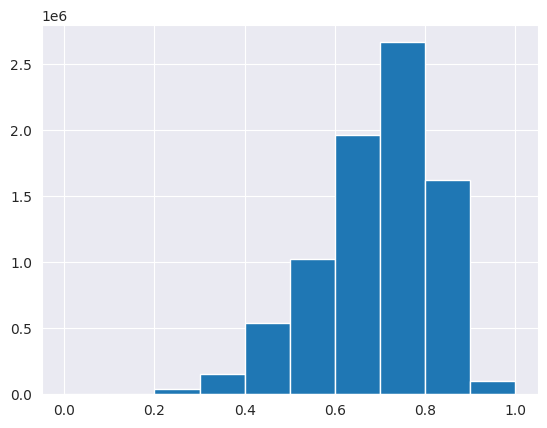

In [14]:
ground_truth_kb_df = pd.DataFrame({'KiloBytes': ground_truth_kb})
ground_truth_kb_df['KiloBytes'].hist()

In [5]:
import os
from utils.model_utils import read_data
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from utils.dataset_preprocessings import INVERSE_PREPROCESSING


dataset = 'FlagsRegression-user20-alpha0.0001-ratio1'
dataset_ = dataset.lower().replace('user', '').replace('alpha', '').replace('ratio', '').split('-')
user, alpha, ratio = dataset_[1], dataset_[2], dataset_[3]
path_prefix = os.path.join('../data', 'FlagsRegression', 'u{}-alpha{}-ratio{}'.format(user, alpha, ratio))
train_data_dir = os.path.join(path_prefix, 'train')
test_data_dir = os.path.join(path_prefix, 'test')
proxy_data_dir = '../data/proxy_data/flags_regression/'
clients, groups, train_data, test_data, proxy_data = read_data('FlagsRegression-user20-alpha0.0001-ratio1', (train_data_dir, test_data_dir, proxy_data_dir))

with open('../centralized_predictions.pkl', 'rb') as handle:
    isolated_predictions = pickle.load(handle)

In [6]:
train_y = np.concatenate([train_data[ap]['y'].numpy().squeeze() for ap in train_data])
#train_y = train_data['f_00019']

<Axes: >

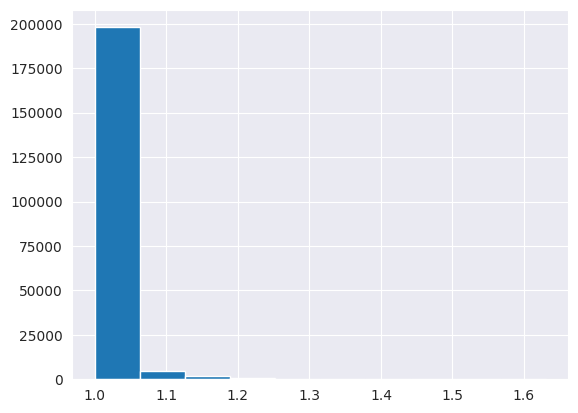

In [7]:
train_data_df = pd.DataFrame({'ScaledY': train_y})
train_data_df['ScaledY'].hist()

<Axes: >

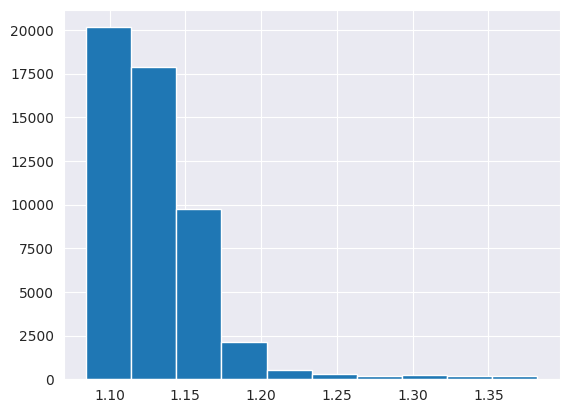

In [8]:
isolated_predictions_df = pd.DataFrame({'ScaledY': isolated_predictions.squeeze()})
isolated_predictions_df['ScaledY'].hist()

In [9]:
unscaled_y = INVERSE_PREPROCESSING['flags-regression'](
                    '../data/FlagsRegression/u20-alpha0.0001-ratio1', 'train',
                    np.repeat([train_y.squeeze()], 6).reshape(-1, 6), axis=0)
unscaled_predictions = INVERSE_PREPROCESSING['flags-regression'](
                    '../data/FlagsRegression/u20-alpha0.0001-ratio1', 'train',
                    np.repeat([isolated_predictions.squeeze()], 6).reshape(-1, 6), axis=0)

In [10]:
unscaled_y

array([ 0.       ,  0.       , 46.52421  , ...,  0.4248375,  4.105475 ,
       13.216309 ], dtype=float32)

In [11]:
unscaled_predictions

array([778.7458 , 602.18787, 695.869  , ..., 638.5353 , 731.41956,
       613.4673 ], dtype=float32)

In [14]:
-np.sort(-unscaled_y)

array([3404.7256, 3404.7256, 3402.8376, ...,    0.    ,    0.    ,
          0.    ], dtype=float32)

In [15]:
-np.sort(-unscaled_predictions)

array([2063.594  , 2063.594  , 2063.594  , ...,  457.65814,  457.606  ,
        456.3759 ], dtype=float32)

## Summation of two GMMs

In [9]:
from pylab import concatenate, normal
from sklearn.mixture import GaussianMixture
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [30]:
normal_distributions = [
    normal(0, 0.1, 1000),
    normal(3, 0.3, 1000)
]
X = concatenate(normal_distributions).reshape(-1, 1)
gmm1 = GaussianMixture(n_components=2, random_state=0).fit(X)

In [31]:
normal_distributions = [
    normal(0, 0.1, 1000),
    normal(1, 0.2, 1000)
]
X = concatenate(normal_distributions).reshape(-1, 1)
gmm2 = GaussianMixture(n_components=2, random_state=0).fit(X)

In [34]:
normal_distributions = [
    gmm1.sample(1000)[0],
    gmm2.sample(1000)[0],
]
X = concatenate(normal_distributions).reshape(-1, 1)
gmm3 = GaussianMixture(n_components=4, random_state=0).fit(X)

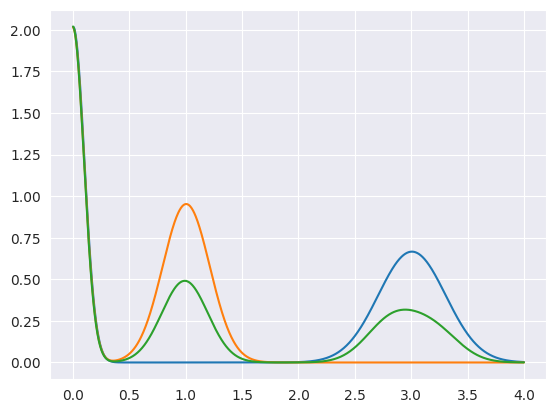

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = np.linspace(0, 4, 1000).reshape(1000,1)

ax.plot(x, np.exp(gmm1.score_samples(x)), '-')
ax.plot(x, np.exp(gmm2.score_samples(x)), '-')
ax.plot(x, np.exp(gmm3.score_samples(x)), '-')
plt.show()